### ```Netflix Data Analysis```

In [1]:
# We are importing necessary libraries for our case study.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### ```Accessing the Data```

In [2]:
#Reading the CSV file from source.

#Creating a Dataframe "df" through and read the CSV file.
df = pd.read_csv("https://raw.githubusercontent.com/allenkong221/netflix-titles-dataset/refs/heads/main/netflix_titles.csv")

#We are fetching the data and looking for 10 data points. Head() gives 5 entries.
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


#### ```Data Preprocessing```

In [3]:
#We will look for the dimensions of the data. we have 6234 rows and 12 columns.
df.shape

(6234, 12)

In [4]:
#We look for the information of the dataset like Datatypes, memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       6234 non-null   int64
 1   type          6234 non-null   str  
 2   title         6234 non-null   str  
 3   director      4265 non-null   str  
 4   cast          5664 non-null   str  
 5   country       5758 non-null   str  
 6   date_added    6223 non-null   str  
 7   release_year  6234 non-null   int64
 8   rating        6224 non-null   str  
 9   duration      6234 non-null   str  
 10  listed_in     6234 non-null   str  
 11  description   6234 non-null   str  
dtypes: int64(2), str(10)
memory usage: 584.6 KB


In [5]:
#We further look into statsitical values of the data we are holding. we are looking irrespective of the integers.
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,6.234000e+03,6234,6234,4265,5664,5758,6223,6234.00000,6224,6234,6234,6234
unique,NaN,2,6172,3301,5469,554,1524,NaN,14,201,461,6226
top,NaN,Movie,Love,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,Documentaries,A surly septuagenarian gets another chance at ...
freq,NaN,4265,3,18,18,2032,122,NaN,2027,1321,299,3
mean,7.670368e+07,NaN,NaN,NaN,NaN,NaN,NaN,2013.35932,NaN,NaN,NaN,NaN
std,1.094296e+07,NaN,NaN,NaN,NaN,NaN,NaN,8.81162,NaN,NaN,NaN,NaN
min,2.477470e+05,NaN,NaN,NaN,NaN,NaN,NaN,1925.00000,NaN,NaN,NaN,NaN
25%,8.003580e+07,NaN,NaN,NaN,NaN,NaN,NaN,2013.00000,NaN,NaN,NaN,NaN
50%,8.016337e+07,NaN,NaN,NaN,NaN,NaN,NaN,2016.00000,NaN,NaN,NaN,NaN
75%,8.024489e+07,NaN,NaN,NaN,NaN,NaN,NaN,2018.00000,NaN,NaN,NaN,NaN


In [6]:
#We will find the number of unique values we have in specific columns.
df.nunique()

show_id         6234
type               2
title           6172
director        3301
cast            5469
country          554
date_added      1524
release_year      72
rating            14
duration         201
listed_in        461
description     6226
dtype: int64

In [7]:
#We will look for null values present in the data. Here we are looking for sum of total null values.
df.isnull().sum()

show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64

```Observations:```
- In the above we can see that Director, cast, date_added, rating & country columns are having null values.

- We can see that director, cast, country has 60% of null values we can simply drop them, we need to impute the null values.
- date_added, rating are around 10% of actual values we can proceed with dropping them.

In [8]:
#we are filling with values to the string columns as we can't imputed numerical values.
df['director'] = df['director'].fillna('no director',inplace=True)
df['cast'] = df['cast'].fillna('cast Unavailable',inplace=True)
df['country'] = df['country'].fillna('country Unavailable',inplace=True)

C:\Users\raksh\AppData\Local\Temp\ipykernel_2080\2325205167.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['director'] = df['director'].fillna('no director',inplace=True)
C:\Users\raksh\AppData\Local\Temp\ipykernel_2080\2325205167.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through ch

In [9]:
#We are dropping the null values in date_added & rating columns.
df.dropna(subset=['date_added','rating'],inplace=True)

In [10]:
# After handling Null values we can see that null values are handled
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [11]:
#Overall Null count we can see that there are no values.
df.isnull().sum().sum()

np.int64(0)

```Observation:```
- We can conclude that the null values are handled.
- The columns are string data we need to replace them with relevant info so we used "No Availability" in place of null values.
- Columns with 10% null values we dropped them.

In [12]:
#To check if there any duplicate rows in the dataset.
df[df.duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


#### ```Feature Engineering```

In [13]:
#We can observe that in the dataset we have two different types.

movies_df = df[df['type'] == 'Movie'].copy()
tv_shows_df = df[df['type'] == 'TV Show'].copy()

In [14]:
# tv_shows_df.head()
movies_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,no director,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...


- we will extract the day, month, year as seperate columns.
- adding to that we add additional columns content age, movie duration time to int as we see 

In [15]:
#we need to convert appropriate columns to respective datatypes
movies_df['release_year'] = movies_df['release_year'].astype(int)
movies_df['date_added'] = movies_df['date_added'].astype('datetime64[ns]')

In [16]:
#We are creating a new seperate columns for year and month.
movies_df['year_added'] = movies_df['date_added'].dt.year
movies_df['month_name'] = movies_df['date_added'].dt.month_name()

In [17]:
#we are creating a column for the age of the content
movies_df['Content_age'] = movies_df['year_added'] - movies_df['release_year']

In [18]:
#we will fetch the duration time integer value and convert to integer.
movies_df['movie_duration_minutes'] = movies_df['duration'].str.extract(r'(\d+)')
movies_df['movie_duration_minutes'] = movies_df['movie_duration_minutes'].astype(int)

#### ```Exploratory Data Analysis [EDA]```

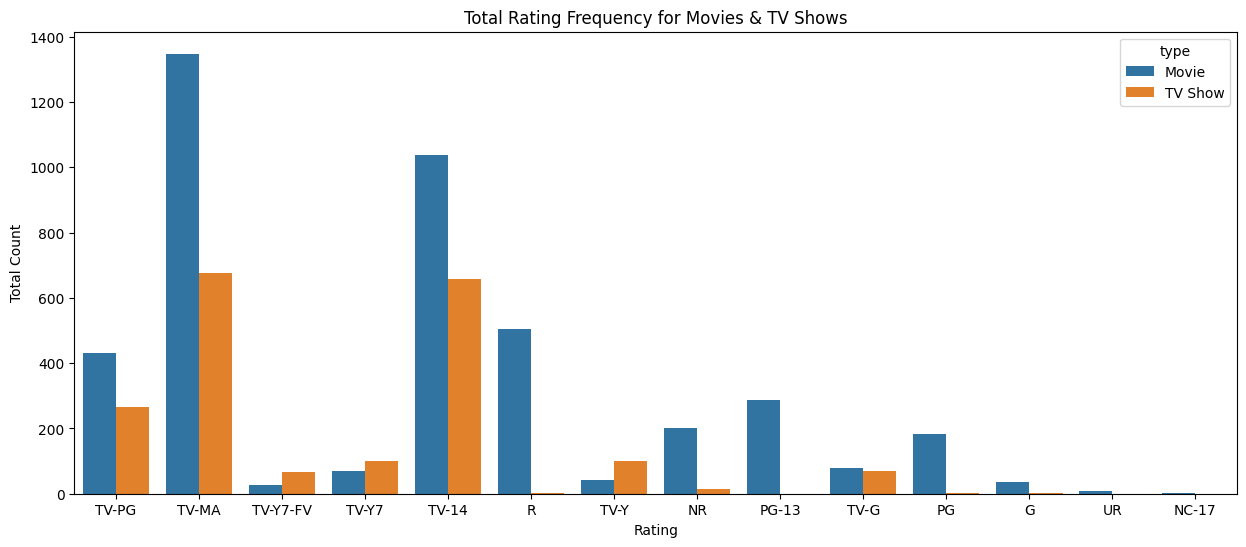

In [19]:
#1. Total count by ratings as a countplot.

total_count = df['rating'].value_counts()
#print(total_count)

#countplot
plt.figure(figsize=(15,6))
sns.countplot(x='rating',data=df,hue='type')
plt.xlabel("Rating")
plt.ylabel("Total Count")
plt.title("Total Rating Frequency for Movies & TV Shows")
plt.show()

Distplot - This shows how numerical data is spread out.

C:\Users\raksh\AppData\Local\Temp\ipykernel_2080\2006776258.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(movies_df["movie_duration_minutes"],bins=20)


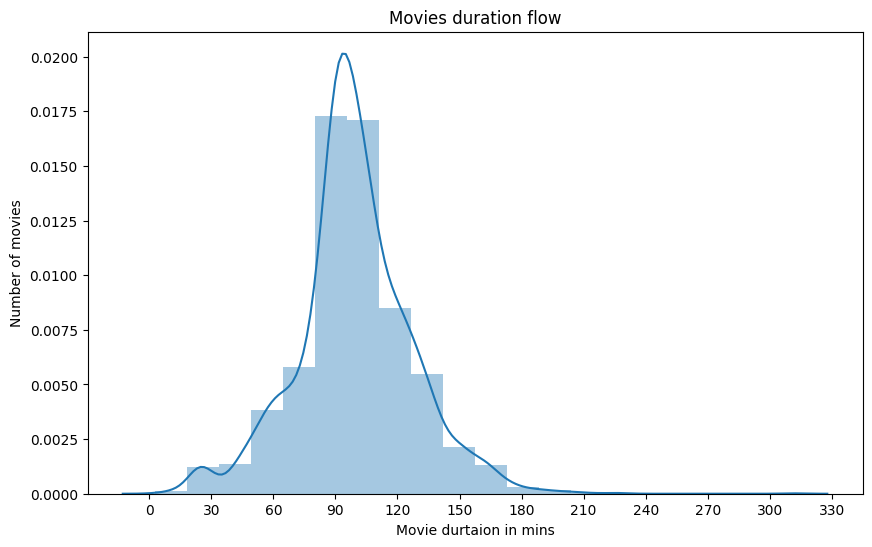

In [23]:
#2. Duration Distribution for Netflix movies as a Distplot.
plt.figure(figsize=(10,6))
sns.distplot(movies_df["movie_duration_minutes"],bins=20)
plt.xticks(np.arange(0,360,30))
plt.xlabel("Movie durtaion in mins")
plt.ylabel("Number of movies")
plt.title("Movies duration flow")
plt.show()

release_year
2017    680
2018    646
2016    592
2019    400
2015    359
Name: show_id, dtype: int64


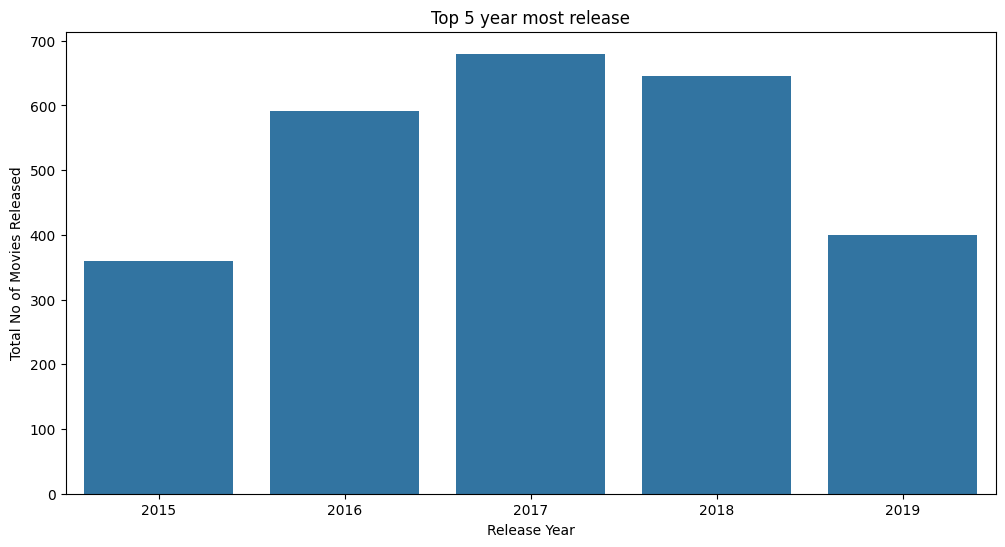

In [26]:
#3. Top 5 years with most releases as a Bar Plot.

top_releases = movies_df.groupby('release_year')['show_id'].count().sort_values(ascending=False).head(5)
print(top_releases)

plt.figure(figsize=(12,6))
sns.barplot(x=top_releases.index,y=top_releases.values)
plt.xlabel("Release Year")
plt.ylabel("Total No of Movies Released")
plt.title("Top 5 year most release")
plt.show()

director
Raúl Campos, Jan Suter    18
Marcus Raboy              14
Jay Karas                 13
Jay Chapman               12
Steven Spielberg           9
Martin Scorsese            9
Johnnie To                 8
David Dhawan               8
Lance Bangs                8
Hakan Algül                7
Name: show_id, dtype: int64


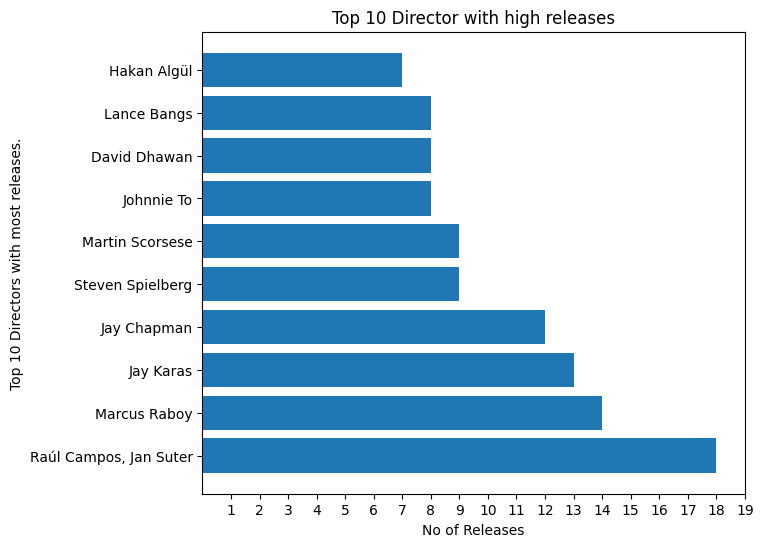

In [27]:
#4. Top 10 Director's with most releases as a horizontal Bar plot.
filtered_director = movies_df[movies_df['director'] != 'no director']
top_directors = filtered_director.groupby('director')['show_id'].count().sort_values(ascending=False).head(10)
print(top_directors)


plt.figure(figsize=(7,6))
plt.barh(top_directors.index,top_directors.values)
plt.xticks(np.arange(1,20))
plt.xlabel("No of Releases")
plt.ylabel("Top 10 Directors with most releases.")
plt.title("Top 10 Director with high releases")
plt.show()

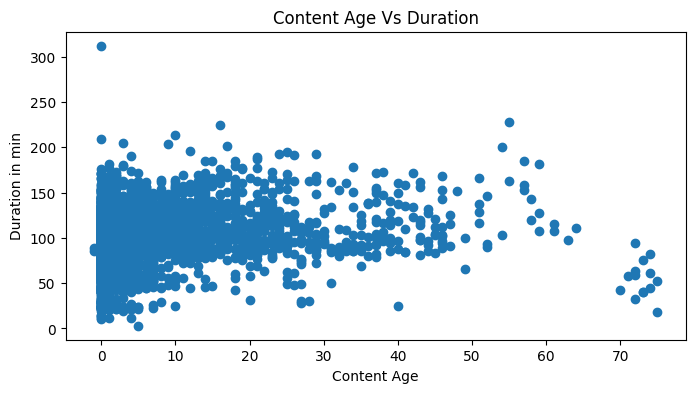

In [ ]:
#5. Content Age vs Duration as a Scatter Plot.

plt.figure(figsize=(8,4))
plt.scatter(movies_df['Content_age'],movies_df['movie_duration_minutes'])
plt.xlabel("Content Age")
plt.ylabel("Duration in min")
plt.title("Content Age Vs Duration")
plt.show()

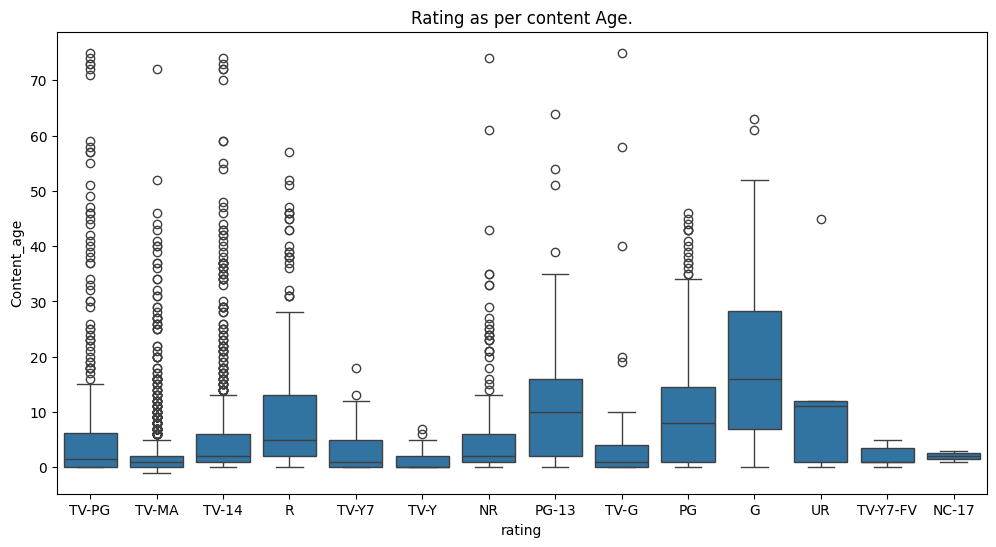

In [ ]:
#6. Content Age by rating as a Box Plot

plt.figure(figsize=(12,6))
sns.boxplot(x='rating',y='Content_age',data=movies_df)
plt.title("Rating as per content Age.")
plt.show()

```Anomaly Detection```

month_name
March        106
October       99
December      88
May           88
September     88
August        77
February      68
April         67
June          66
January       58
Name: show_id, dtype: int64


C:\Users\raksh\AppData\Local\Temp\ipykernel_2080\842392091.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=months_spikes.index,y=months_spikes.values, palette='coolwarm')


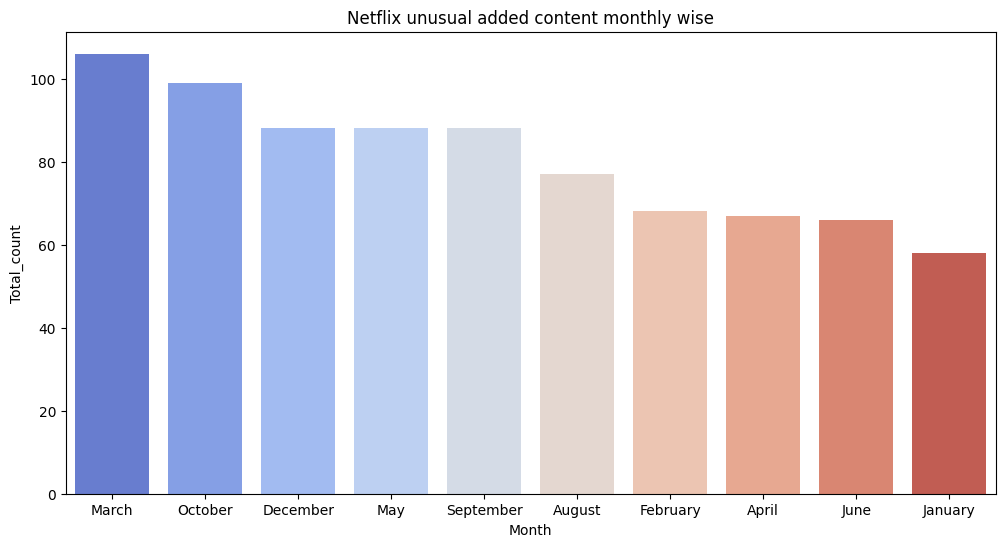

In [30]:
#7. Find months where netflix added unsually high or low volumes of content.

target_year = 2017

filtered_year = movies_df[movies_df['year_added'] == target_year]
months_spikes = filtered_year.groupby('month_name')['show_id'].count().sort_values(ascending=False).head(10)
print(months_spikes)

plt.figure(figsize=(12,6))
sns.barplot(x=months_spikes.index,y=months_spikes.values, palette='coolwarm')
plt.xlabel("Month")
plt.ylabel('Total_count')
plt.title("Netflix unusual added content monthly wise")
plt.show()

#8. Detect Outliers using Z-score.

<Figure size 1600x500 with 0 Axes>

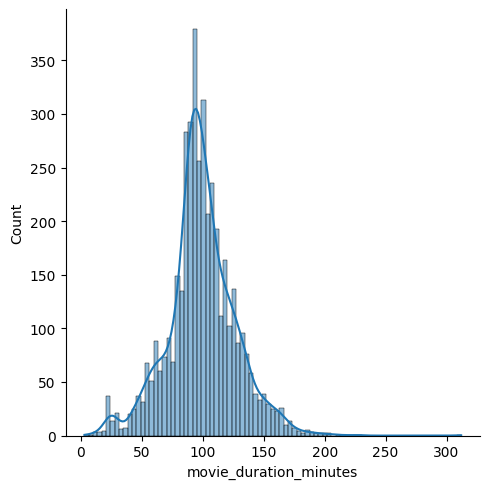

In [ ]:
plt.figure(figsize=(16,5))
sns.displot(movies_df['movie_duration_minutes'],kde=True)
plt.show()

In [ ]:
print("Mean value of Movie duration minutes",movies_df['movie_duration_minutes'].mean())
print("Std value of Movie Duration minutes",movies_df['movie_duration_minutes'].std())
print("Minimum value of Movie Duration minutes",movies_df['movie_duration_minutes'].min())
print("Maximum value of Movie Duration minutes",movies_df['movie_duration_minutes'].max())

Mean value of Movie duration minutes 99.15644820295984
Std value of Movie Duration minutes 28.05661822956427
Minimum value of Movie Duration minutes 3
Maximum value of Movie Duration minutes 312


In [ ]:
#Finding the boundaries
print("Highest",movies_df['movie_duration_minutes'].mean() + 3*movies_df['movie_duration_minutes'].std())
print("Lowest",movies_df['movie_duration_minutes'].mean() - 3*movies_df['movie_duration_minutes'].std())

Highest 183.32630289165263
Lowest 14.986593514267028


In [ ]:
#Finding the Outliers
movies_df[(movies_df['movie_duration_minutes'] > 183.32) | (movies_df['movie_duration_minutes'] < 14.98)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_name,Content_age,movie_duration_minutes
44,81176188,Movie,American Factory: A Conversation with the Obamas,no director,"President Barack Obama, Michelle Obama, Julia ...",country Unavailable,2019-09-05,2019,TV-G,10 min,Documentaries,Barack and Michelle Obama talk with directors ...,2019,September,0,10
494,81211714,Movie,The Road to El Camino: Behind the Scenes of El...,no director,cast Unavailable,United States,2019-10-29,2019,TV-14,14 min,"Documentaries, International Movies","Aaron Paul, Vince Gilligan and other cast memb...",2019,October,0,14
635,81035749,Movie,The Gospel of Luke,David Batty,"Selva Rasalingam, Karima Gouit, Mourad Zaoui, ...","United States, United Kingdom, Morocco",2018-10-19,2015,TV-14,205 min,"Dramas, Faith & Spirituality",Word-for-word Bible texts of the entire book o...,2018,October,3,205
637,81035751,Movie,The Gospel of Matthew,David Batty,"Selva Rasalingam, Mourad Zaoui, Karima Gouit, ...",country Unavailable,2018-10-19,2014,TV-14,190 min,"Dramas, Faith & Spirituality",The Apostle Matthew is highlighted in this wor...,2018,October,4,190
870,70090035,Movie,Jodhaa Akbar,Ashutosh Gowariker,"Hrithik Roshan, Aishwarya Rai Bachchan, Sonu S...",India,2018-10-01,2008,TV-14,214 min,"Action & Adventure, Dramas, International Movies","In 16th-century India, what begins as a strate...",2018,October,10,214
1100,80175798,Movie,The Irishman,Martin Scorsese,"Robert De Niro, Al Pacino, Joe Pesci, Harvey K...",United States,2019-11-27,2019,R,209 min,Dramas,Hit man Frank Sheeran looks back at the secret...,2019,November,0,209
1360,449931,Movie,Doctor Zhivago,David Lean,"Omar Sharif, Julie Christie, Geraldine Chaplin...","United States, Italy, United Kingdom, Liechten...",2019-11-01,1965,PG-13,200 min,"Classic Movies, Dramas, Romantic Movies",A young physician and his beautiful mistress g...,2019,November,54,200
1395,60011729,Movie,Mutiny on the Bounty,"Lewis Milestone, Carol Reed","Marlon Brando, Trevor Howard, Richard Harris, ...",United States,2019-11-01,1962,TV-PG,185 min,"Action & Adventure, Classic Movies, Dramas",Marlon Brando gives a nuanced performance as t...,2019,November,57,185
1446,81020543,Movie,Calico Critters: A Town of Dreams,Momoko Kamiya,cast Unavailable,country Unavailable,2018-11-01,2017,TV-Y,11 min,Children & Family Movies,Freya heads into town with her mother for a ve...,2018,November,1,11
2363,80059049,Movie,Pardes,Subhash Ghai,"Shah Rukh Khan, Amrish Puri, Mahima Chaudhry, ...",India,2018-03-01,1997,TV-14,187 min,"Dramas, International Movies, Romantic Movies","Prompted by loyalty, Arjun plays matchmaker be...",2018,March,21,187


In [ ]:
#Calculate Z-Score

movies_df['duration_z_score'] = (movies_df['movie_duration_minutes'] - movies_df['movie_duration_minutes'].mean()) / movies_df['movie_duration_minutes'].std()

movies_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_name,Content_age,movie_duration_minutes,duration_z_score
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,2019,September,0,90,-0.326356
1,80117401,Movie,Jandino: Whatever it Takes,no director,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,2016,September,0,94,-0.183787
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,2017-09-08,2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...,2017,September,0,99,-0.005576
6,70304989,Movie,Automata,Gabe Ibáñez,"Antonio Banderas, Dylan McDermott, Melanie Gri...","Bulgaria, United States, Spain, Canada",2017-09-08,2014,R,110 min,"International Movies, Sci-Fi & Fantasy, Thrillers","In a dystopian future, an insurance adjuster f...",2017,September,3,110,0.386488
7,80164077,Movie,Fabrizio Copano: Solo pienso en mi,"Rodrigo Toro, Francisco Schultz",Fabrizio Copano,Chile,2017-09-08,2017,TV-MA,60 min,Stand-Up Comedy,Fabrizio Copano takes audience participation t...,2017,September,0,60,-1.395623


In [ ]:
movies_df[movies_df['duration_z_score'] > 3].value_counts().sum() #21
movies_df[movies_df['duration_z_score'] < -3].value_counts().sum() #7

np.int64(7)

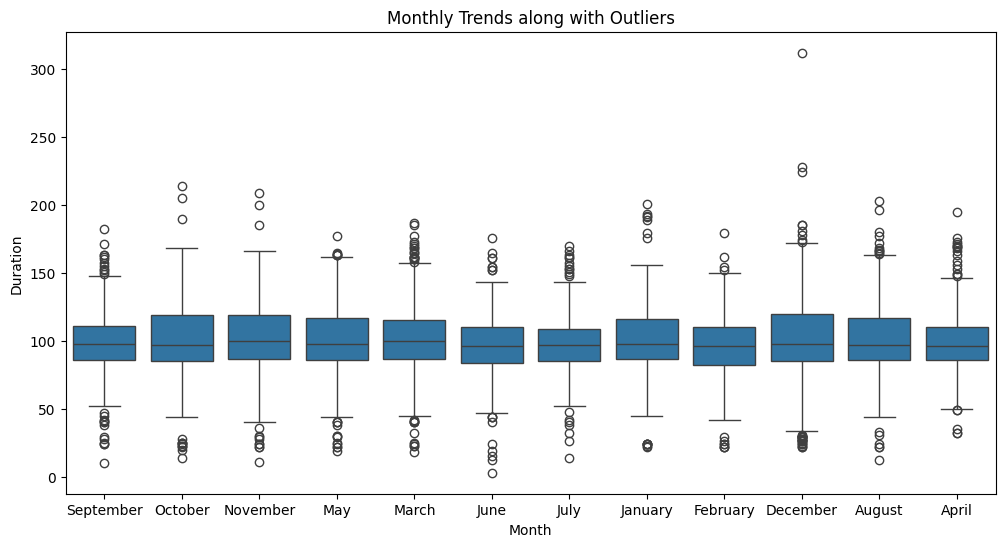

In [31]:
#9. Visualize monthly trends along with outliers.

plt.figure(figsize=(12,6))
sns.boxplot(x='month_name',y='movie_duration_minutes', data=movies_df)
plt.xlabel("Month")
plt.ylabel("Duration")
plt.title("Monthly Trends along with Outliers")
plt.show()